# Titanic Dataset Analysis
## Assignment 2 — Data Cleaning, Feature Engineering & Feature Selection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
sns.set(style='whitegrid')

In [2]:
df = pd.read_csv('../data/train.csv')
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Part 1: Data Cleaning

### 1.1 Missing Values
- **Age**: ~20% missing → fill with median (safer than mean for skewed data)
- **Embarked**: 2 missing → fill with mode
- **Cabin**: ~77% missing → drop the column (too sparse to impute meaningfully)
- **Fare**: 1 missing in test set → fill with median

In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nPercentage missing:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Percentage missing:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [4]:
# Fill Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Fill Fare with median 
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# Drop Cabin column
df.drop(columns=['Cabin'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_14948\1733419892.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_14948\1733419892.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

### 1.2 Outlier Handling
Fare has a long right tail. We cap at the 99th percentile to reduce the effect of extreme values.

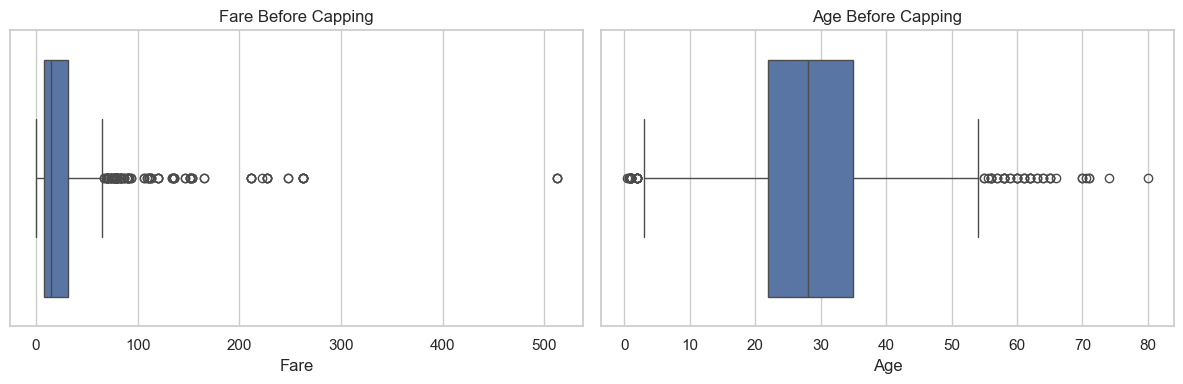

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Fare'], ax=axes[0])
axes[0].set_title('Fare Before Capping')
sns.boxplot(x=df['Age'], ax=axes[1])
axes[1].set_title('Age Before Capping')
plt.tight_layout()
plt.show()

In [6]:
# Cap Fare and Age at 99th percentile
fare_cap = df['Fare'].quantile(0.99)
age_cap = df['Age'].quantile(0.99)

df['Fare'] = df['Fare'].clip(upper=fare_cap)
df['Age'] = df['Age'].clip(upper=age_cap)

print(f"Fare capped at: {fare_cap:.2f}")
print(f"Age capped at: {age_cap:.2f}")

Fare capped at: 249.01
Age capped at: 65.00


### 1.3 Data Consistency

In [7]:
# Standardize Sex values
df['Sex'] = df['Sex'].str.lower().str.strip()
print("Sex unique values:", df['Sex'].unique())

# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Sex unique values: ['male' 'female']
Duplicate rows: 0


In [8]:
# Save cleaned data
df.to_csv('../data/train_cleaned.csv', index=False)
print("Saved train_cleaned.csv")
print("Shape:", df.shape)

Saved train_cleaned.csv
Shape: (891, 11)


## Part 2: Feature Engineering

### 2.1 Derived Features

In [9]:
# FamilySize and IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head())

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1


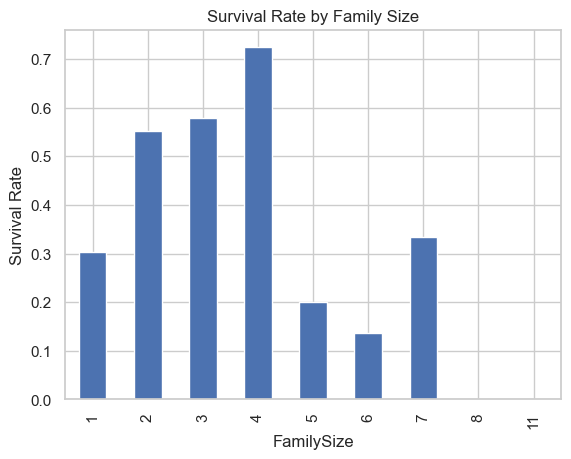

In [10]:
# Survival rate by FamilySize
df.groupby('FamilySize')['Survived'].mean().plot(kind='bar', title='Survival Rate by Family Size')
plt.ylabel('Survival Rate')
plt.show()

In [11]:
# Extract Title from Name
df['Title'] = df['Name'].apply(lambda x: re.search(r',\s*(\w+)\.', x).group(1) if re.search(r',\s*(\w+)\.', x) else 'Unknown')

print("Title value counts:")
print(df['Title'].value_counts())

Title value counts:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Unknown       1
Jonkheer      1
Name: count, dtype: int64


In [12]:
# Group rare titles into 'Other'
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
df['Title'] = df['Title'].apply(lambda x: x if x in common_titles else 'Other')

print("Survival rate by Title:")
print(df.groupby('Title')['Survived'].mean())

Survival rate by Title:
Title
Master    0.575000
Miss      0.697802
Mr        0.156673
Mrs       0.792000
Other     0.444444
Name: Survived, dtype: float64


In [13]:
# Deck — Cabin was dropped, so we set Deck = 'Unknown'
df['Deck'] = 'Unknown'
print("Deck created as Unknown (Cabin was dropped due to high missingness)")

Deck created as Unknown (Cabin was dropped due to high missingness)


In [14]:
# Age groups
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("Survival rate by AgeGroup:")
print(df.groupby('AgeGroup')['Survived'].mean())

Survival rate by AgeGroup:
AgeGroup
Child     0.579710
Teen      0.428571
Adult     0.365753
Senior    0.227273
Name: Survived, dtype: float64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_14948\722870350.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['Survived'].mean())


In [15]:
# Fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
print(df['FarePerPerson'].describe())

count    891.000000
mean      19.161062
std       28.386818
min        0.000000
25%        7.250000
50%        8.300000
75%       23.666667
max      249.006220
Name: FarePerPerson, dtype: float64


### 2.2 Categorical Encoding

In [16]:
# One-hot encode nominal features
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title', 'Deck', 'AgeGroup'], drop_first=False)
print("Shape after encoding:", df.shape)

Shape after encoding: (891, 27)


### 2.3 Feature Transformations

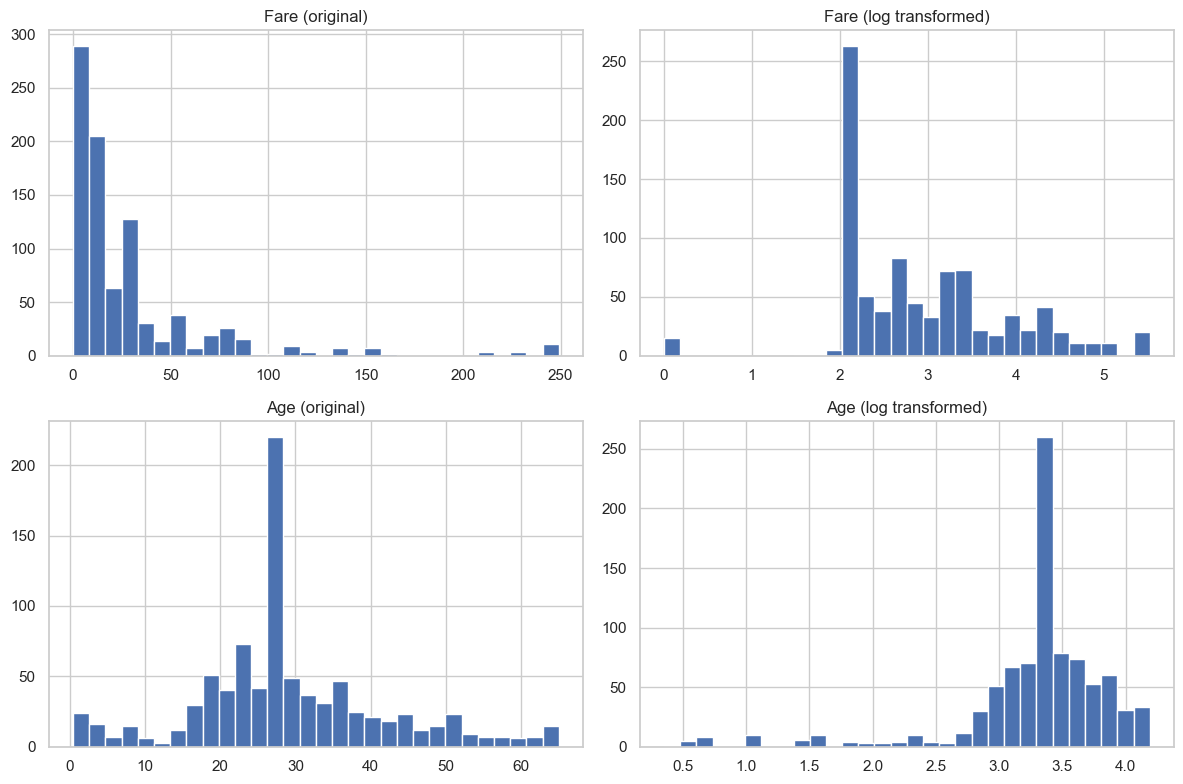

In [17]:
# Log transform skewed features
df['Fare_log'] = np.log1p(df['Fare'])
df['Age_log'] = np.log1p(df['Age'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df['Fare'].hist(ax=axes[0, 0], bins=30)
axes[0, 0].set_title('Fare (original)')
df['Fare_log'].hist(ax=axes[0, 1], bins=30)
axes[0, 1].set_title('Fare (log transformed)')
df['Age'].hist(ax=axes[1, 0], bins=30)
axes[1, 0].set_title('Age (original)')
df['Age_log'].hist(ax=axes[1, 1], bins=30)
axes[1, 1].set_title('Age (log transformed)')
plt.tight_layout()
plt.show()

In [18]:
df.to_csv('../data/train_engineered.csv', index=False)
print("Saved train_engineered.csv")

Saved train_engineered.csv


## Part 3: Feature Selection

### 3.1 Drop Irrelevant Columns

In [19]:
df_sel = pd.read_csv('../data/train_engineered.csv')

# Drop columns not useful for modeling
df_sel.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
print("Shape after dropping irrelevant columns:", df_sel.shape)

Shape after dropping irrelevant columns: (891, 26)


### 3.2 Correlation Analysis

In [20]:
numeric_df = df_sel.select_dtypes(include=[np.number])
corr_matrix = numeric_df.drop(columns=['Survived'], errors='ignore').corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Highly correlated features to drop:", to_drop)
df_sel.drop(columns=to_drop, inplace=True, errors='ignore')

Highly correlated features to drop: []


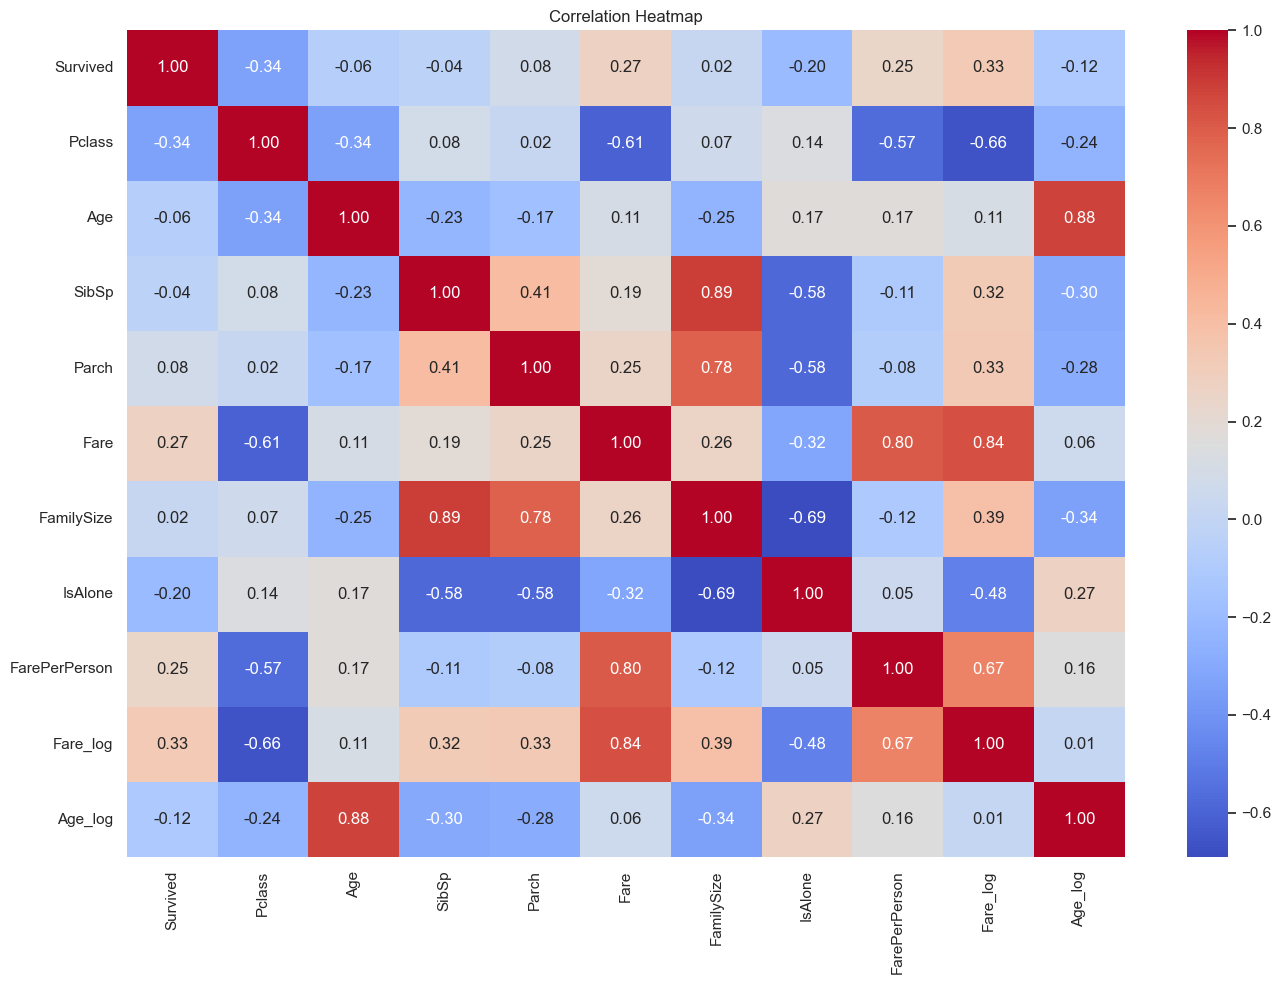

In [21]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
numeric_cols = df_sel.select_dtypes(include=[np.number]).columns[:15]
sns.heatmap(df_sel[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### 3.3 Feature Importance (Random Forest)

In [22]:
X = df_sel.drop(columns=['Survived'])
y = df_sel['Survived']

# Encode any remaining object/bool columns
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.astype(float)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(15).to_string(index=False))

      Feature  Importance
     Title_Mr    0.119817
FarePerPerson    0.106731
         Fare    0.105418
     Fare_log    0.102856
      Age_log    0.100054
          Age    0.097622
     Sex_male    0.080300
   Sex_female    0.067942
       Pclass    0.042129
   FamilySize    0.035175
        SibSp    0.025533
    Title_Mrs    0.023192
   Title_Miss    0.015430
        Parch    0.012109
   Embarked_S    0.010991


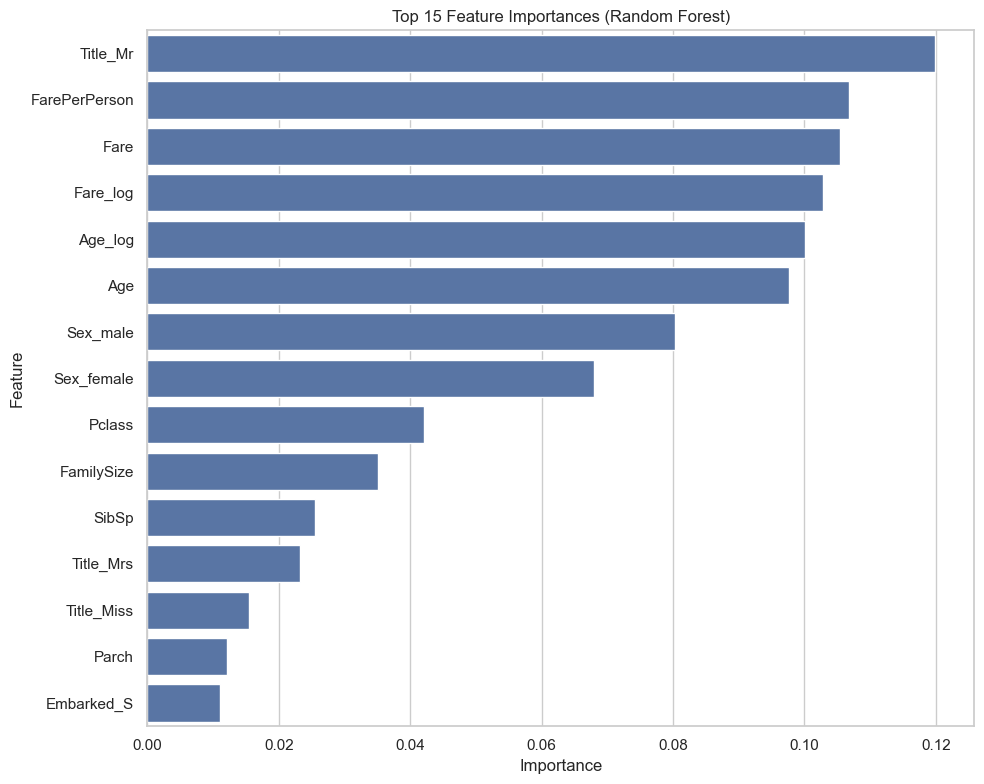

In [23]:
# Plot feature importances
plt.figure(figsize=(10, 8))
top15 = importance_df.head(15)
sns.barplot(x='Importance', y='Feature', data=top15)
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [24]:
# Keep features with importance > 0.01
top_features = importance_df[importance_df['Importance'] > 0.01]['Feature'].tolist()
print(f"Selected {len(top_features)} features:")
print(top_features)

final_cols = top_features + ['Survived']
df_final = df_sel[[c for c in final_cols if c in df_sel.columns]]
df_final.to_csv('../data/train_selected.csv', index=False)
print("\nSaved train_selected.csv")

Selected 15 features:
['Title_Mr', 'FarePerPerson', 'Fare', 'Fare_log', 'Age_log', 'Age', 'Sex_male', 'Sex_female', 'Pclass', 'FamilySize', 'SibSp', 'Title_Mrs', 'Title_Miss', 'Parch', 'Embarked_S']

Saved train_selected.csv


## Summary

**Data Cleaning:**
- Imputed Age and Embarked with median/mode; dropped Cabin (77% missing)
- Capped Fare and Age outliers at the 99th percentile
- Standardized Sex values to lowercase

**Feature Engineering:**
- Created FamilySize, IsAlone, Title, AgeGroup, FarePerPerson
- One-hot encoded Sex, Embarked, Title, Deck, AgeGroup
- Applied log transform to Fare and Age to reduce skewness

**Feature Selection:**
- Dropped PassengerId, Name, Ticket as irrelevant identifiers
- Removed highly correlated features (threshold > 0.95)
- Used Random Forest importance to keep features with importance > 0.01